In [4]:
import sys
# change the system path to the partent directory of the current file, so that we can import the QNN framework
sys.path.append("..")

In [5]:
# Necessary imports

import numpy as np
import matplotlib.pyplot as plt

from qiskit_machine_learning.utils import algorithm_globals

# Set seed for random generators
algorithm_globals.random_seed = 654213873

from QNN_framework import Reuploading_classifier
from data_loading import Build_artitifical_data_set

from qiskit_machine_learning.optimizers import COBYLA, L_BFGS_B, AQGD, ADAM

In [61]:
import numpy as np
import matplotlib.pyplot as plt

# X: your training points, shape (n_samples, 2)
# y: true labels
# estimator_classifier: your trained NeuralNetworkClassifier

def plot_decision_boundary(model, X, y, h=0.02, padding=0.3):
    x_min, x_max = X[:, 0].min() - padding, X[:, 0].max() + padding
    y_min, y_max = X[:, 1].min() - padding, X[:, 1].max() + padding

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = np.array(Z).reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.35, cmap="viridis")
    plt.contour(xx, yy, Z, levels=np.unique(Z), colors="k", linewidths=0.8, alpha=0.6)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis", edgecolors="k", s=30)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title("Decision boundary")
    plt.show()

In [7]:
from qiskit.circuit import QuantumCircuit, ParameterVector

def SU2(parameter_prefix="θ", **kwargs):
    qc = QuantumCircuit(2)
    reps = 2
    params = ParameterVector(parameter_prefix, length=reps * 4)

    for i in range(reps):
        for j in range(2):
            qc.rx(params[i * 4 + j], j)
            qc.ry(params[i * 4 + 2 + j], j)
        if i%2:
            qc.cx(0, 1)
        else:
            qc.cx(1, 0)
    return qc

In [70]:
# Generate random dataset

# Select dataset dimension (num_inputs) and size (num_samples)
n_class = 2
num_samples = 200
# Select dataset dimension (num_inputs) and size (num_samples)
n_feature = 2

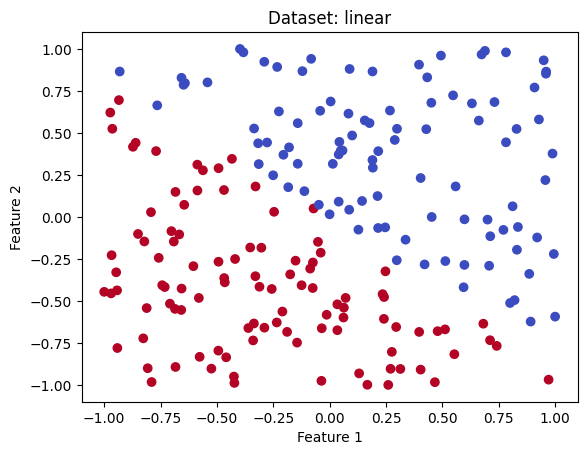

In [79]:

X_linear, y_linear = Build_artitifical_data_set(name="linear", n_samples=num_samples, n_features=n_feature, n_classes=2,display=True)

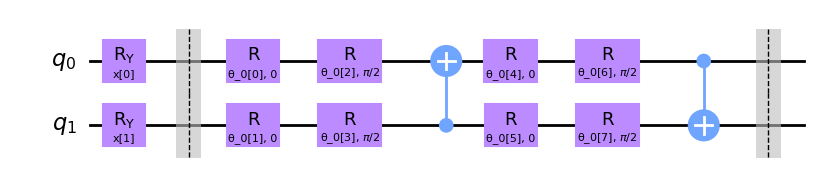

In [81]:

args_embeding= {"name": "real_amp", "circular": True, "reps": 0}
args_anzats= {"name": "brickwall", "circular": True, "reps": 0}

# construct neural network classifier
estimator_classifier_linear = Reuploading_classifier(
    n_feature=n_feature,
    n_class=n_class,
    qnn_args=dict(
        reps=0,
        anzats_build=SU2,
        args_embeding=args_embeding,
        args_anzats=args_anzats,
        pre_anzats=False,
        padding = 0.5
    ),
    optimizer=COBYLA(maxiter=100, rhobeg=0.4),
)

estimator_classifier_linear.neural_network.circuit.decompose().draw(output="mpl", style="clifford")


In [82]:
# fit classifier to data
estimator_classifier_linear.fit(X_linear, y_linear)

estimator_classifier_linear.score(X_linear, y_linear)

0.955

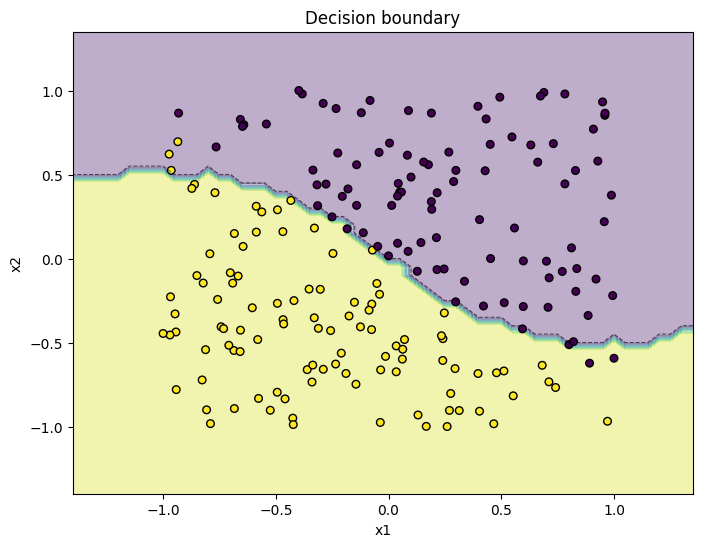

In [83]:
plot_decision_boundary(estimator_classifier_linear, X_linear, y_linear , h = 0.05, padding=0.4)

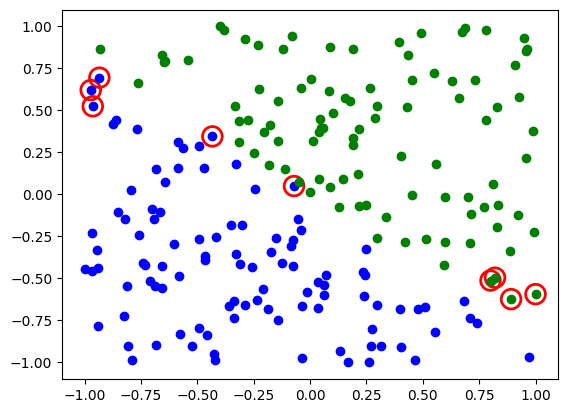

In [84]:
# evaluate data points
y_predict = estimator_classifier_linear.predict(X_linear)

# plot results
# red == wrongly classified
for x, y_target, y_p in zip(X_linear, y_linear, y_predict):
    if y_target == 1:
        plt.plot(x[0], x[1], "bo")
    else:
        plt.plot(x[0], x[1], "go")
    if y_target != y_p:
        plt.scatter(x[0], x[1], s=200, facecolors="none", edgecolors="r", linewidths=2)
plt.show()

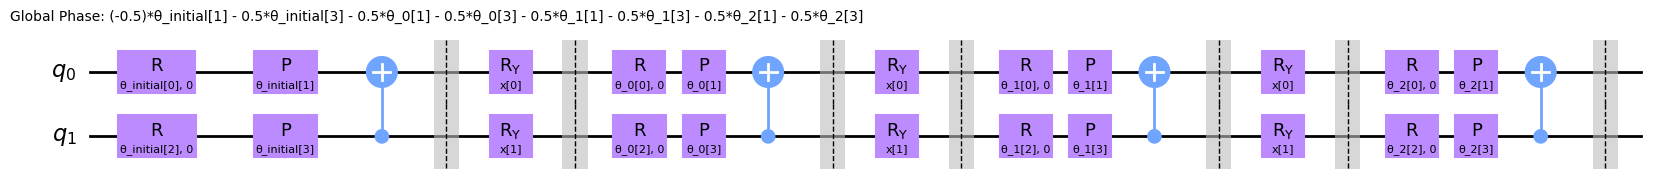

In [35]:
args_embeding= {"name": "real_amp", "circular": True, "reps": 0}
args_anzats= {"name": "brickwall", "circular": True, "reps": 0}
reps = 2
n_feature = 2
num_samples = 400
qnn_args = dict(
    reps=reps,
    args_embeding=args_embeding,
    args_anzats=args_anzats,
    pre_anzats=True
)

estimator_classifier = Reuploading_classifier(
    n_feature=n_feature,
    n_class=n_class,
    qnn_args=qnn_args,
    optimizer=COBYLA(maxiter=100,rhobeg=0.4)
    #optimizer=L_BFGS_B(maxiter=50)
)

estimator_classifier.neural_network.circuit.decompose().draw(output="mpl", style="clifford")

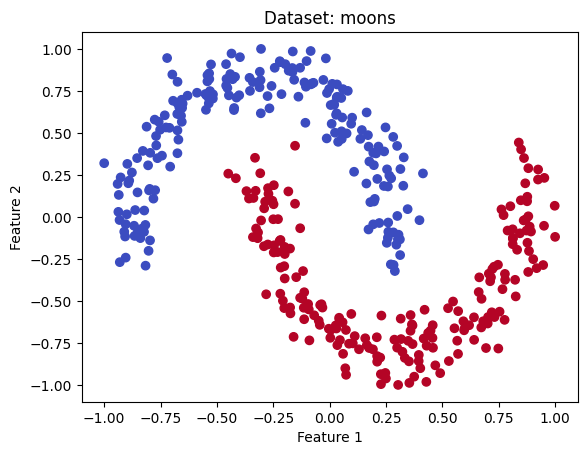

In [36]:
X,y = Build_artitifical_data_set(name="moons", n_samples=num_samples, n_features=n_feature, n_classes=2, display=True)

Classifier score: 0.9925


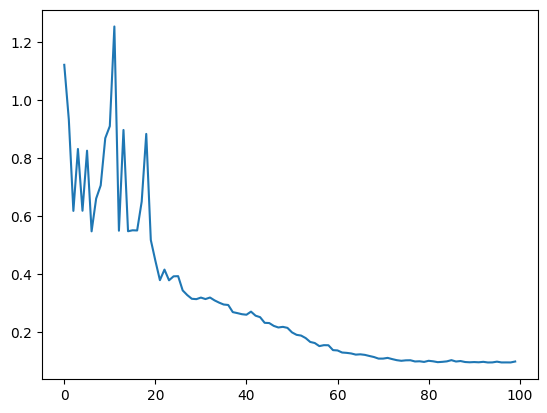

In [37]:
# fit classifier to data
estimator_classifier.fit(X, y)
# score classifier
score = estimator_classifier.score(X, y)
print(f"Classifier score: {score}")
obj_func_gradient = estimator_classifier.objective_func_vals
plt.plot(obj_func_gradient)

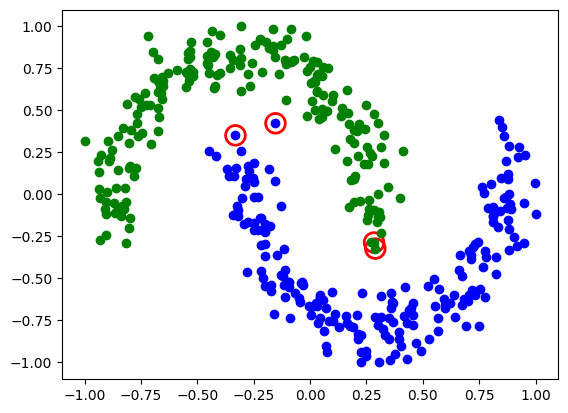

Classifier score on test set: 0.9925


In [38]:
# evaluate data points
test_y_predict = estimator_classifier.predict(X)

# plot results
# red == wrongly classified
for x, y_target, y_p in zip(X, y, test_y_predict):
    if y_target == 1:
        plt.plot(x[0], x[1], "bo")
    else:
        plt.plot(x[0], x[1], "go")
    if y_target != y_p:
        plt.scatter(x[0], x[1], s=200, facecolors="none", edgecolors="r", linewidths=2)
plt.show()

score = estimator_classifier.score(X, y)
print(f"Classifier score on test set: {score}")

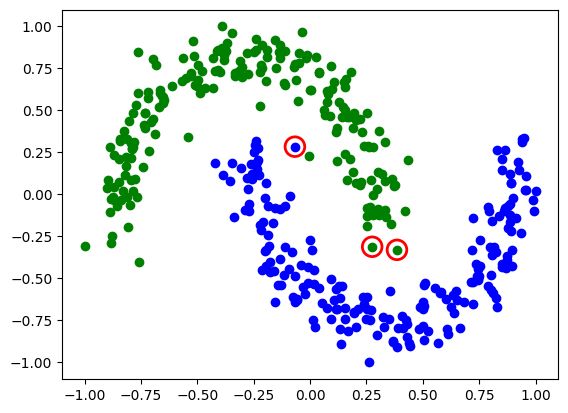

Classifier score on test set: 0.9925


In [39]:
test_X, test_y = Build_artitifical_data_set(name="moons", n_samples=num_samples, n_features=n_feature, n_classes=2, seed = 234)

# evaluate data points
test_y_predict = estimator_classifier.predict(test_X)

# plot results
# red == wrongly classified
for x, y_target, y_p in zip(test_X, test_y, test_y_predict):
    if y_target == 1:
        plt.plot(x[0], x[1], "bo")
    else:
        plt.plot(x[0], x[1], "go")
    if y_target != y_p:
        plt.scatter(x[0], x[1], s=200, facecolors="none", edgecolors="r", linewidths=2)
plt.show()

score = estimator_classifier.score(test_X, test_y)
print(f"Classifier score on test set: {score}")

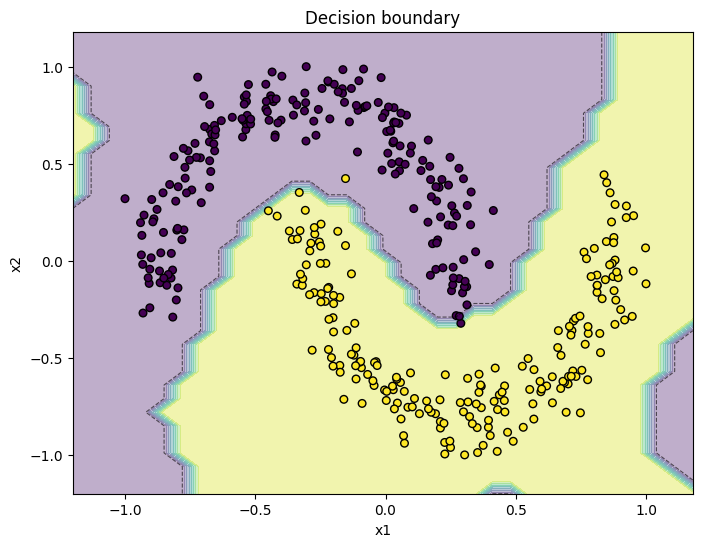

In [40]:
plot_decision_boundary(estimator_classifier, X, y, h=0.07, padding=0.2)

In [17]:
n_feature = 8
num_samples = 1000

X,y = Build_artitifical_data_set(name="classification", n_samples=1000, n_features=8, n_classes=2)

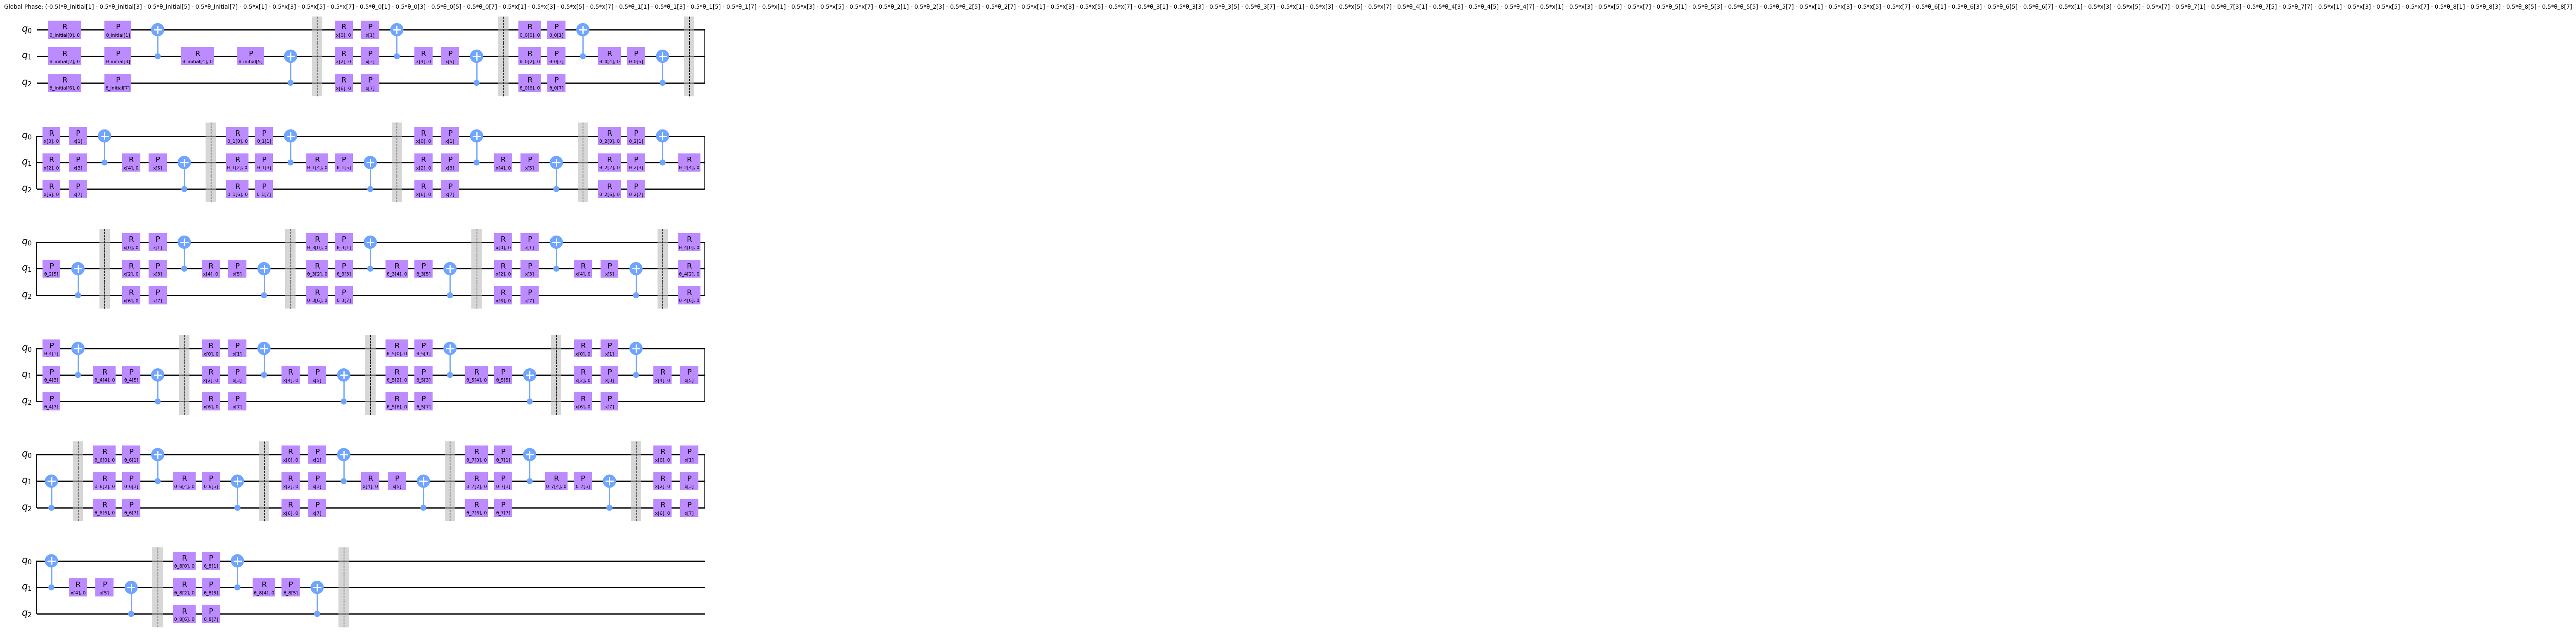

In [ ]:
args_embeding= {"name": "brickwall", "circular": True, "reps": 1}
args_anzats= {"name": "brickwall", "circular": True, "reps": 0}
reps = 8
qnn_args = dict(
    reps=reps,
    args_embeding=args_embeding,
    args_anzats=args_anzats,
    pre_anzats=True
)

estimator_classifier = Reuploading_classifier(
    n_feature=n_feature,
    n_class=n_class,
    qnn_args=qnn_args,
    optimizer=COBYLA(maxiter=100,rhobeg=0.4)
    #optimizer=L_BFGS_B(maxiter=50)
)

estimator_classifier.neural_network.circuit.decompose().draw(output="mpl", style="clifford")

Classifier score: 0.355


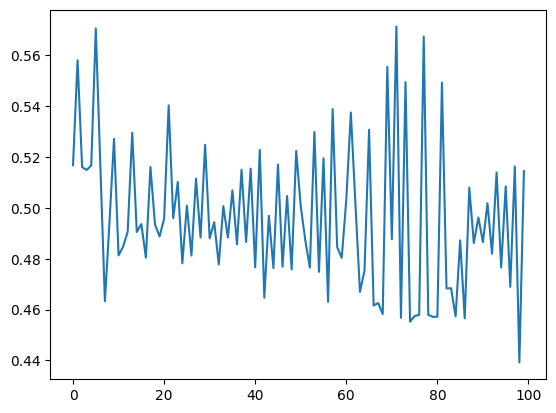

In [19]:
# fit classifier to data
estimator_classifier.fit(X, y)
# score classifier
score = estimator_classifier.score(X, y)
print(f"Classifier score: {score}")
obj_func_gradient = estimator_classifier.objective_func_vals
plt.plot(obj_func_gradient)